In [42]:
# Task 1: Data Cleaning & Preprocessing


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [43]:
df = pd.read_csv("/content/Titanic-Dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [44]:
#First 5 records
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [45]:
#Number of rows and columns
print("Shape of dataset:", df.shape)

Shape of dataset: (891, 12)


In [46]:
#Data types + non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [47]:
#Statistical summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [48]:
#Missing values per column
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [49]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [50]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": missing_percentage
})

missing_table

,Missing Values,Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


In [51]:
df = df.drop(columns=["Cabin", "PassengerId"])

print("Columns after removing unnecessary columns:")
print(df.columns)

Columns after removing unnecessary columns:
Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='object')


In [52]:
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [53]:
print("Missing Age values before:", df["Age"].isnull().sum())

Missing Age values before: 177


In [54]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [55]:
print("Missing Age values after:", df["Age"].isnull().sum())

Missing Age values after: 0


In [56]:
print(df["Embarked"].value_counts())

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [57]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [58]:
print("Missing Embarked values:", df["Embarked"].isnull().sum())

Missing Embarked values: 0


In [59]:
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Embarked    0
dtype: int64


In [60]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [61]:
#Encode categorical variables
print(df.dtypes)


Survived      int64
Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Embarked     object
dtype: object


In [62]:
df = pd.get_dummies(
    df,
    columns=["Sex", "Embarked"],
    drop_first=True
)

In [63]:
df.head()

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [64]:
print(df.dtypes)

Survived        int64
Pclass          int64
Name           object
Age           float64
SibSp           int64
Parch           int64
Ticket         object
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [65]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (891, 11)

Missing values:
Survived      0
Pclass        0
Name          0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Data types:
Survived        int64
Pclass          int64
Name           object
Age           float64
SibSp           int64
Parch           int64
Ticket         object
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object


In [66]:
df.head()

,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,True,False,True
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,False,False,False
2,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,False,False,True
4,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,True,False,True


In [67]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(list(numerical_columns))

Numerical columns:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


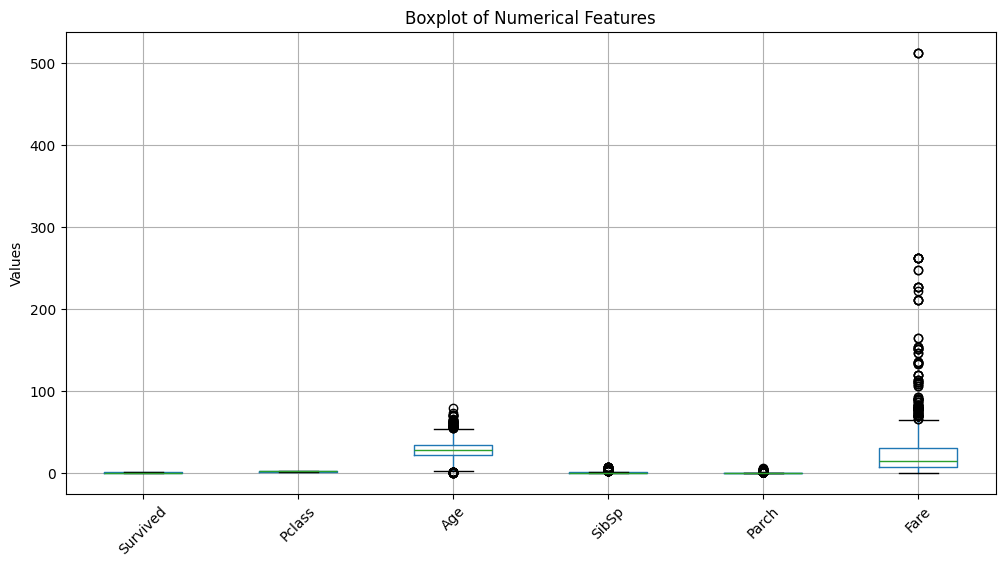

In [68]:
plt.figure(figsize=(12, 6))

df[numerical_columns].boxplot()

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.ylabel("Values")
plt.show()

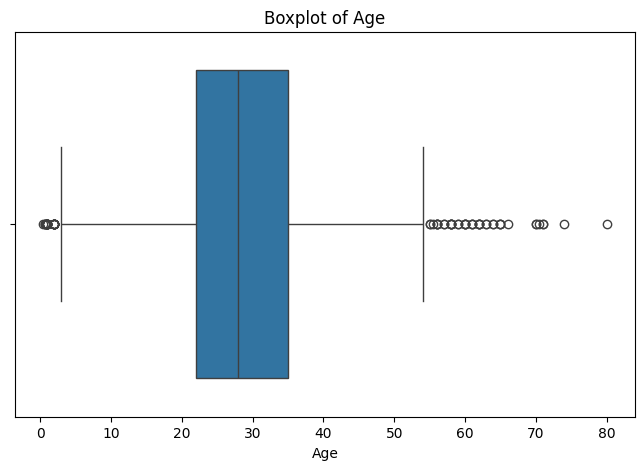

In [69]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Age"])

plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()

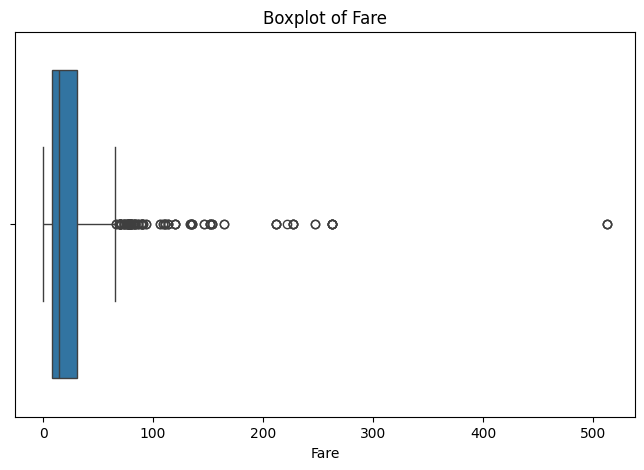

In [70]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["Fare"])

plt.title("Boxplot of Fare")
plt.xlabel("Fare")
plt.show()

In [71]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Q1: 7.9104
Q3: 31.0
IQR: 23.0896
Lower Bound: -26.724
Upper Bound: 65.6344


In [72]:
fare_outliers = df[
    (df["Fare"] < lower_bound) |
    (df["Fare"] > upper_bound)
]

print("Number of Fare outliers:", len(fare_outliers))

Number of Fare outliers: 116


In [73]:
df_cleaned = df[
    (df["Fare"] >= lower_bound) &
    (df["Fare"] <= upper_bound)
].copy()

In [74]:
print("Original dataset shape:", df.shape)
print("After outlier removal:", df_cleaned.shape)

Original dataset shape: (891, 11)
After outlier removal: (775, 11)


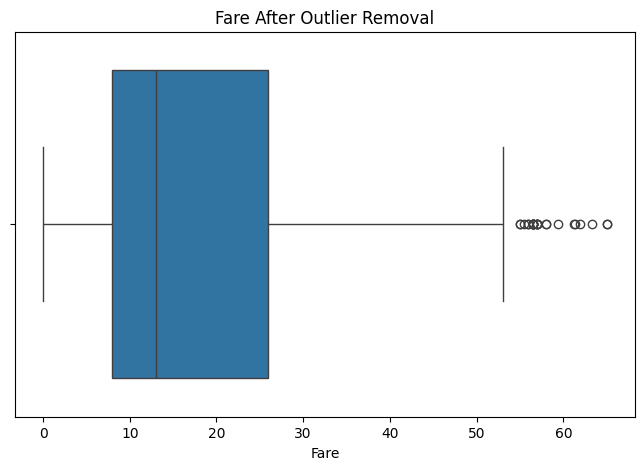

In [75]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df_cleaned["Fare"])

plt.title("Fare After Outlier Removal")
plt.xlabel("Fare")
plt.show()

In [76]:
from sklearn.preprocessing import StandardScaler

In [77]:
scaler = StandardScaler()

df_cleaned[["Age", "Fare"]] = scaler.fit_transform(
    df_cleaned[["Age", "Fare"]]
)

In [78]:
df_cleaned[["Age", "Fare"]].head()

,Age,Fare
0,-0.528321,-0.779117
2,-0.215182,-0.729373
3,0.489381,2.599828
4,0.489381,-0.720161
5,-0.058613,-0.690071


In [79]:
print("Final dataset shape:", df_cleaned.shape)

print("\nMissing values:")
print(df_cleaned.isnull().sum())

print("\nFinal columns:")
print(df_cleaned.columns.tolist())

print("\nFirst 5 rows:")
display(df_cleaned.head())

Final dataset shape: (775, 11)

Missing values:
Survived      0
Pclass        0
Name          0
Age           0
SibSp         0
Parch         0
Ticket        0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

Final columns:
['Survived', 'Pclass', 'Name', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Sex_male', 'Embarked_Q', 'Embarked_S']

First 5 rows:


,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,"Braund, Mr. Owen Harris",-0.528321,1,0,A/5 21171,-0.779117,True,False,True
2,1,3,"Heikkinen, Miss. Laina",-0.215182,0,0,STON/O2. 3101282,-0.729373,False,False,True
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.489381,1,0,113803,2.599828,False,False,True
4,0,3,"Allen, Mr. William Henry",0.489381,0,0,373450,-0.720161,True,False,True
5,0,3,"Moran, Mr. James",-0.058613,0,0,330877,-0.690071,True,True,False


In [80]:
print("\nFinal dataset information:")
df_cleaned.info()


Final dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 775 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    775 non-null    int64  
 1   Pclass      775 non-null    int64  
 2   Name        775 non-null    object 
 3   Age         775 non-null    float64
 4   SibSp       775 non-null    int64  
 5   Parch       775 non-null    int64  
 6   Ticket      775 non-null    object 
 7   Fare        775 non-null    float64
 8   Sex_male    775 non-null    bool   
 9   Embarked_Q  775 non-null    bool   
 10  Embarked_S  775 non-null    bool   
dtypes: bool(3), float64(2), int64(4), object(2)
memory usage: 56.8+ KB


In [81]:
df_cleaned.to_csv("titanic_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## Conclusion

In this task, I performed data cleaning and preprocessing on the Titanic dataset.

### Steps completed:
- Loaded and explored the dataset
- Checked data types and missing values
- Removed unnecessary columns
- Handled missing numerical values using median imputation
- Handled missing categorical values using mode imputation
- Converted categorical variables into numerical values using one-hot encoding
- Detected outliers using boxplots and the IQR method
- Removed Fare outliers
- Standardized numerical features using StandardScaler
- Saved the cleaned dataset as `titanic_cleaned.csv`

### Key Learning

Data preprocessing is an important step in machine learning because raw data may contain missing values, categorical variables, different feature scales, and outliers. Cleaning and transforming the data prepares it for further machine learning analysis.